# A PLATO catalogue of AGNs

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.time import Time
from astropy import units as u
from astropy import constants as c
from ipywidgets import *

# PlatoSim libraries
import platosim.utilities as ut
import platosim.plot      as pt
import platosim.noise     as ns
from platosim.lightcurve   import LightCurve
from platosim.slurm        import workerOverview
from platosim.matplotlibrc import setup_notebook
setup_notebook()

In [3]:
# Paths to where data is stored
path = '/lhome/nicholas/software/workdir/smbhb'
fdir = '/lhome/nicholas/Nextcloud/paperSMBHB/figures'

---
## Quasar Gaia DR3 catalogue
---

The catalogues presenetd in this section were generated using `picsim`:

```
python picsim.py --vizier LOPS1 --gaia_quasar --magmax 19 --project smbhb
python picsim.py --vizier LOPN1 --gaia_quasar --magmax 19 --project smbhb
```

In [4]:
# Load catalogues and merge to one
df_LOPS2 = pd.read_feather(f'{path}/input/starcat_GaiaDR3_LOPS2.ftr')
df_LOPN1 = pd.read_feather(f'{path}/input/starcat_GaiaDR3_LOPN1.ftr')
df = pd.concat([df_LOPS2, df_LOPN1])

# Add redshift relative error
df.z_error = np.abs(df.z_upper - df.z_lower) / df.z

# Number of objects
df.shape[0]

19269

### 0. General cuts

In [5]:
# Start make some general cuts
dt0 = df[(df.class_name == 'AGN') & 
         (df. p_comb_quasar > 0.999) & 
         (df.z > 0.09) & 
         (df.z_error < 0.05) &
         (df.Pmag < 19)]
dt0 = dt0.sort_values(by='Pmag', ascending=False)
dt0.p_comb_quasar *= 100

# Number of objects
dt0.shape[0]

12598

### 1. Decontamination cut using proper motion

In [6]:
# Define decontamination line
G_line = np.linspace(5, 19, 100)
mu_line = 10**(0.4*(G_line - 18.25))

# Mark outliers
mu = 10**(0.4*(dt0.Pmag - 18.25))
do1 = dt0[(dt0.pm > mu)]
dt1 = dt0[(dt0.pm < mu)]

# Number of objects
dt1.shape[0]

12586

<IPython.core.display.Javascript object>


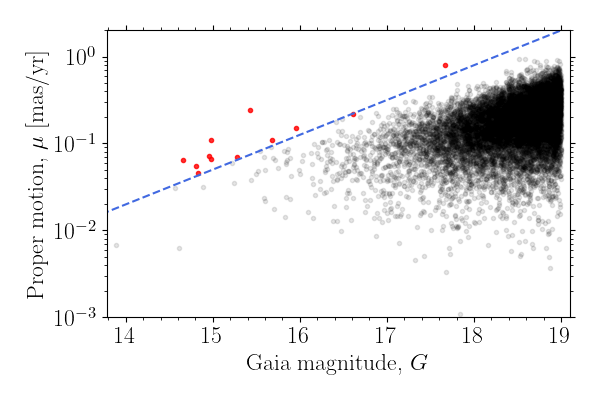

In [8]:
# Plot decontamination
fig = plt.figure(figsize=(6,4))
plt.plot(dt1.Pmag, dt1.pm, '.', c='k', alpha=0.1)
plt.plot(do1.Pmag, do1.pm, '.', c='r', alpha=0.8)
plt.plot(G_line, mu_line, '--', c='royalblue')
plt.xlabel(r'Gaia magnitude, $G$')
plt.ylabel(r'Proper motion, $\mu$ [mas/yr]')
plt.yscale('log')
plt.xlim(min(dt1.Pmag)-0.1, max(dt1.Pmag)+0.1)
plt.ylim(1e-3, 2e0)
plt.tight_layout();

### 3. Astrometric fidelity cut (Rubizki+2022)

### 2. QSO probability cut

In [9]:
# Remove sources below black line above
do2 = dt1
def y(x): return x 
dt2 = dt1[(10**dt1.qso_non > 2.5) & (dt1.qso_non > y(dt1.qso_var))]

# Number of objects
dt2.shape[0]

12022

<IPython.core.display.Javascript object>


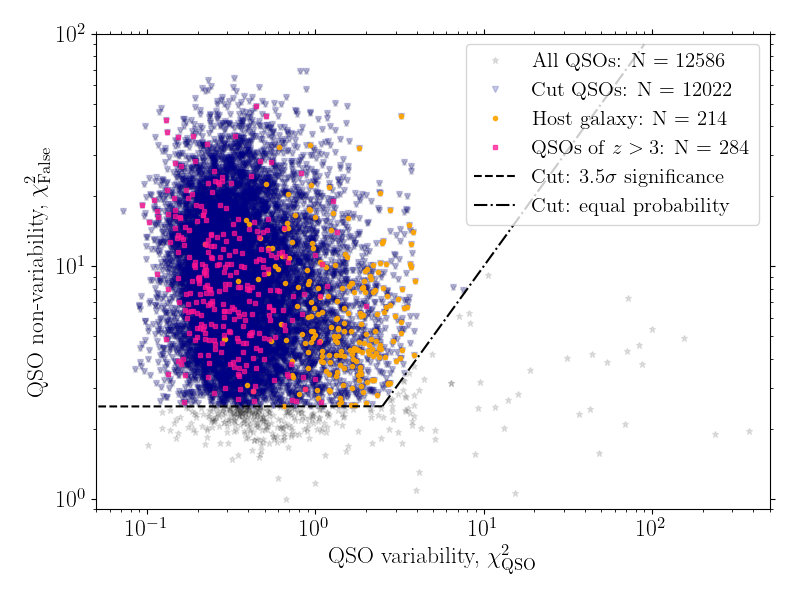

In [10]:
# Plot diagnostic diagram of Butler and Bloom (2011)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Check how many of the AGNs that has a confirmed host galaxy
dh2 = dt2[(dt2.host_galaxy == True)]

# All quasar above z > 3
ds2 = dt2[dt2.z > 3]

# Plotting
ax.plot(10**do2.qso_var, 10**do2.qso_non, '*', c='k',        alpha=0.1, ms=5, label=f'All QSOs: N = {do2.shape[0]}')
ax.plot(10**dt2.qso_var, 10**dt2.qso_non, 'v', c='darkblue', alpha=0.2, ms=5, label=f'Cut QSOs: N = {dt2.shape[0]}')
ax.plot(10**dh2.qso_var, 10**dh2.qso_non, '.', c='orange',   alpha=0.9,       label=f'Host galaxy: N = {dh2.shape[0]}')
ax.plot(10**ds2.qso_var, 10**ds2.qso_non, 's', c='deeppink', alpha=0.7, ms=3, label=r'QSOs of $z>3$: ' + f'N = {ds2.shape[0]}')
ax.plot([0, 2.5], [1, 2.5],         '--', c='k', label=r'Cut: 3.5$\sigma$ significance')
ax.plot([2.5, 90], [y(2.5), y(90)], '-.', c='k', label='Cut: equal probability')
# ax.axvline(x=2.0,         ls='--', c='deeppink', label=r'Cut: higher purity for $z>3$')

# Settings
ax.legend()
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'QSO variability, $\chi_{\rm QSO}^2$')
ax.set_ylabel(r'QSO non-variability, $\chi_{\rm False}^2$')
ax.set_xlim(5e-2, 5e2)
ax.set_ylim(0.9, 100)
plt.tight_layout();

# Save figure
fig.savefig(f'{fdir}/variability_QSO.png', bbox_inches='tight', dpi=300)

### 3. Compare to Quaia catalogue (Storey-Fisher+2024)

In [11]:
# Load Quaia catalogue
filename = f'{path}/quaia_G20.5.fits'
from astropy.table import Table
data = Table.read(filename, format='fits')
dx3 = data.to_pandas()
dx3.head()

,source_id,unwise_objid,redshift_quaia,redshift_quaia_err,ra,dec,l,b,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,mag_w1_vg,mag_w2_vg,pm,pmra,pmdec,pmra_error,pmdec_error
0,6459630980096,b'0453p000o0014479',0.416867,0.060812,44.910498,0.189649,176.659434,-48.835164,20.173105,20.200150,18.871586,14.774343,13.923867,0.383797,0.217806,-0.316007,0.679419,0.608799
1,10892037246720,b'0453p000o0015876',1.736468,0.096594,45.188575,0.282424,176.851544,-48.570856,18.787239,19.080688,18.240915,15.219950,13.868094,0.155406,-0.098037,-0.120580,0.257395,0.223107
2,15839839588736,b'0453p000o0017020',1.513049,0.063187,45.189480,0.359195,176.769129,-48.516842,18.888464,19.171280,18.509371,15.317786,14.013617,0.448925,-0.316088,0.318781,0.360595,0.326582
3,19275813399552,b'0453p000o0024506',2.422632,0.055260,44.835496,0.237432,176.527928,-48.855622,20.330523,20.320410,19.841410,17.273508,16.396996,1.085342,1.062588,0.221073,0.739487,0.625105
4,22780506725760,b'0453p000o0016209',2.852854,0.076640,44.799365,0.303557,176.417664,-48.835309,19.218422,19.486340,18.814501,16.027142,15.041919,0.523211,0.168237,0.495425,0.361439,0.269473


In [12]:
# Match catalogues
dt2.gaiaDR3 = dt2.gaiaDR3.astype(np.int64)
dt3 = dt2[dt2['gaiaDR3'].isin(dx3['source_id'])].sort_values(by=['gaiaDR3']).reset_index(drop=True)
dx3 = dx3[dx3['source_id'].isin(dt3['gaiaDR3'])].sort_values(by=['source_id']).reset_index(drop=True)

# Number of objects
dt3.shape[0]

11859

In [13]:
# Sperate LOPS2 and LOPN1
ds3 = dt3[dt3.dec < 0]
dn3 = dt3[dt3.dec > 0]

ds3.shape[0], dn3.shape[0]

(5533, 6326)

In [31]:
dt3

,starID,designation,gaiaDR3,ra,dec,Pmag,BP_RP,Ag,plx,plx_err,...,p_spec_quasar,z,z_upper,z_lower,class_name,qso_var,qso_non,agn_score,host_galaxy,ncams
0,949,1309048754137266048,1309048754137266048,258.531179,30.021946,18.337816,0.624743,0.0063,-0.046818,0.106815,...,0.995161,1.443808,1.448970,1.438657,AGN,-0.424330,1.733484,0.186371,False,6
1,675,1309086790367974528,1309086790367974528,257.869603,30.090549,18.734226,0.498865,0.0027,-0.005135,0.151615,...,0.055124,1.148483,1.156445,1.140550,AGN,-0.487186,1.254607,0.663765,False,6
2,1076,1309202312104774656,1309202312104774656,257.031438,30.066804,18.772522,0.709314,0.0502,-0.090427,0.150730,...,0.990574,2.049299,2.060719,2.037921,AGN,-0.554339,0.542776,0.924953,False,6
3,945,1309238802146770560,1309238802146770560,256.261351,30.115323,17.753103,0.623503,0.0031,-0.040082,0.075380,...,0.060191,1.202726,1.208574,1.196894,AGN,-0.592430,0.593821,0.779812,False,6
4,515,1309397681577168640,1309397681577168640,257.585293,30.984908,17.849737,0.344170,0.0012,-0.149920,0.085044,...,0.913792,0.664326,0.670252,0.658421,AGN,-0.485288,1.212187,0.669411,False,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11854,2689,5608249891458615680,5608249891458615680,103.349688,-30.575228,18.985479,0.497578,0.0013,-0.212458,0.160446,...,0.984130,0.568947,0.575499,0.562423,AGN,-0.316882,0.824886,0.805669,False,6
11855,2727,5608275077147335552,5608275077147335552,103.362868,-30.265876,18.746462,0.573605,0.0064,-0.041828,0.150028,...,0.062910,2.065630,2.074586,2.056700,AGN,-0.614298,0.997791,0.825352,False,6
11856,2791,5608294112442801024,5608294112442801024,103.877456,-30.042880,18.226046,0.706570,NaN,-0.080458,0.114818,...,1.000000,0.365800,0.366643,0.364956,AGN,-0.185314,0.870280,0.695350,False,6
11857,2721,5608310124081038336,5608310124081038336,103.685356,-29.946853,18.237661,0.556614,0.0010,-0.069556,0.124950,...,0.979977,0.857263,0.862092,0.852446,AGN,-0.578425,1.108079,0.764471,False,6


### Plots for paper 

<IPython.core.display.Javascript object>


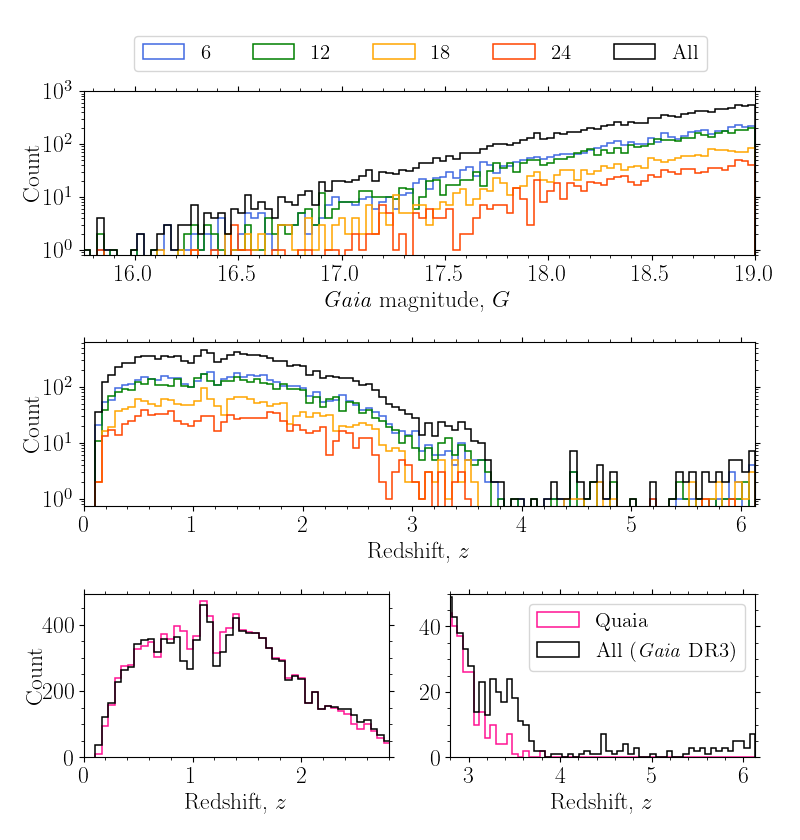

In [28]:
# Seperate camera visibility
dt06 = dt3[dt3.ncams ==  6]
dt12 = dt3[dt3.ncams == 12]
dt18 = dt3[dt3.ncams == 18]
dt24 = dt3[dt3.ncams == 24]

# Plot settings
N = 100
lw = 1.1
c = ['royalblue', 'green', 'orange', 'orangered', 'k']
cols = 3

# fig = plt.figure(cols, 1, figsize=(9,3*cols))  # For thesis
fig = plt.figure(figsize=(8,2.8*cols))  # For paper

ax1 = plt.subplot(3, 1, 1)
P_min, P_max = dt3.Pmag.min(), dt3.Pmag.max()
ax1.hist(dt06.Pmag, bins=N, range=(P_min, P_max), histtype='step', ec=c[0], lw=lw, label='6')
ax1.hist(dt12.Pmag, bins=N, range=(P_min, P_max), histtype='step', ec=c[1], lw=lw, label='12')
ax1.hist(dt18.Pmag, bins=N, range=(P_min, P_max), histtype='step', ec=c[2], lw=lw, label='18')
ax1.hist(dt24.Pmag, bins=N, range=(P_min, P_max), histtype='step', ec=c[3], lw=lw, label='24')
ax1.hist(dt3.Pmag,  bins=N, range=(P_min, P_max), histtype='step', ec=c[4], lw=lw, label='All')
ax1.set_xlabel(r'\textit{Gaia} magnitude, $G$')
ax1.set_xlim(P_min, 19)
ax1.set_ylim(0.8, 1000)
# ax1.legend(loc='upper left')  # For thesis
ax1.legend(loc='upper left', bbox_to_anchor=(0.06, 1.4), ncols=5)
ax1.set_yscale('log')

ax2 = plt.subplot(3, 1, 2)
z_min, z_max = dt3.z.min(), dt3.z.max()
ax2.hist(dt06.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[0], lw=lw)
ax2.hist(dt12.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[1], lw=lw)
ax2.hist(dt18.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[2], lw=lw)
ax2.hist(dt24.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[3], lw=lw)
ax2.hist(dt3.z,  bins=N, range=(z_min, z_max), histtype='step', ec=c[4], lw=lw)
ax2.set_xlabel(r'Redshift, $z$')
ax2.set_xlim(0, z_max)
ax2.set_yscale('log')

z_break = 2.8
ax3 = plt.subplot(3, 2, 5)
ax3.hist(dx3.redshift_quaia, bins=N, range=(z_min, z_max), histtype='step', ec='deeppink', lw=lw)
ax3.hist(dt3.z, bins=N, range=(z_min, z_max), histtype='step', ec='k', lw=lw)
ax3.set_xlabel(r'Redshift, $z$')
ax3.set_xlim(0, z_break)

ax4 = plt.subplot(3, 2, 6)
ax4.hist(dx3.redshift_quaia, bins=N, range=(z_min, z_max), histtype='step', ec='deeppink', lw=lw, label='Quaia')
ax4.hist(dt3.z, bins=N, range=(z_min, z_max), histtype='step', ec='k', lw=lw, label=r'All (\textit{Gaia} DR3)')
ax4.set_xlabel(r'Redshift, $z$')
ax4.set_xlim(z_break, z_max)
ax4.set_ylim(0, 50)
ax4.legend(loc='upper right')

for ax in [ax1, ax2, ax3]:
    ax.set_ylabel('Count')
    if ax == ax3:
        ax.get_yaxis().set_label_coords(-0.12, 0.5)
    else:
        ax.get_yaxis().set_label_coords(-0.06, 0.5)
plt.tight_layout()

fig.savefig(f'{fdir}/historgram_quasars.png', bbox_inches='tight', dpi=300)

In [ ]:
# Seperate camera visibility
dt06 = ds3[ds3.ncams ==  6]
dt12 = ds3[ds3.ncams == 12]
dt18 = ds3[ds3.ncams == 18]
dt24 = ds3[ds3.ncams == 24]

# Plot settings
N = 100
lw = 1.1
c = ['royalblue', 'green', 'orange', 'orangered', 'k']
cols = 2

# fig = plt.figure(figsize=(8, 2*cols))  # For paper
fig = plt.figure(figsize=(10,3*cols))  # For thesis

ax1 = plt.subplot(2, 1, 1)
P_min, P_max = ds3.Pmag.min(), ds3.Pmag.max()
ax1.hist(dt06.Pmag, bins=N, range=(P_min, P_max), histtype='step', ec=c[0], lw=lw, label='6')
ax1.hist(dt12.Pmag, bins=N, range=(P_min, P_max), histtype='step', ec=c[1], lw=lw, label='12')
ax1.hist(dt18.Pmag, bins=N, range=(P_min, P_max), histtype='step', ec=c[2], lw=lw, label='18')
ax1.hist(dt24.Pmag, bins=N, range=(P_min, P_max), histtype='step', ec=c[3], lw=lw, label='24')
ax1.hist(ds3.Pmag,  bins=N, range=(P_min, P_max), histtype='step', ec=c[4], lw=lw, label='All')
ax1.set_xlabel(r'\textit{Gaia} magnitude, $G$')
ax1.set_xlim(P_min, 19)
ax1.set_ylim(0.8, 1000)
ax1.legend(loc='upper left')
ax1.set_yscale('log')

ax2 = plt.subplot(2, 1, 2)
z_min, z_max = ds3.z.min(), ds3.z.max()
ax2.hist(dt06.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[0], lw=lw)
ax2.hist(dt12.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[1], lw=lw)
ax2.hist(dt18.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[2], lw=lw)
ax2.hist(dt24.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[3], lw=lw)
ax2.hist(ds3.z,  bins=N, range=(z_min, z_max), histtype='step', ec=c[4], lw=lw)
ax2.set_xlabel(r'Redshift, $z$')
ax2.set_xlim(0, z_max)

for ax in [ax1, ax2]:
    ax.set_ylabel('Count')
    if ax == ax3:
        ax.get_yaxis().set_label_coords(-0.12, 0.5)
    else:
        ax.get_yaxis().set_label_coords(-0.06, 0.5)
plt.tight_layout()

In [ ]:
# Seperate camera visibility
dt06 = dn3[dn3.ncams ==  6]
dt12 = dn3[dn3.ncams == 12]
dt18 = dn3[dn3.ncams == 18]
dt24 = dn3[dn3.ncams == 24]

# Plot settings
N = 100
lw = 1.1
c = ['royalblue', 'green', 'orange', 'orangered', 'k']
cols = 2

# fig, ax = plt.subplots(cols, 1, figsize=(9,3*cols))
fig = plt.figure(figsize=(10,3*cols))

ax1 = plt.subplot(2, 1, 1)
P_min, P_max = dn3.Pmag.min(), dn3.Pmag.max()
ax1.hist(dt06.Pmag, bins=N, range=(P_min, P_max), histtype='step', ec=c[0], lw=lw, label='6')
ax1.hist(dt12.Pmag, bins=N, range=(P_min, P_max), histtype='step', ec=c[1], lw=lw, label='12')
ax1.hist(dt18.Pmag, bins=N, range=(P_min, P_max), histtype='step', ec=c[2], lw=lw, label='18')
ax1.hist(dt24.Pmag, bins=N, range=(P_min, P_max), histtype='step', ec=c[3], lw=lw, label='24')
ax1.hist(dn3.Pmag,  bins=N, range=(P_min, P_max), histtype='step', ec=c[4], lw=lw, label='All')
ax1.set_xlabel(r'\textit{Gaia} magnitude, $G$')
ax1.set_xlim(P_min, 19)
ax1.set_ylim(0.8, 1000)
ax1.legend(loc='upper left')
ax1.set_yscale('log')

ax2 = plt.subplot(2, 1, 2)
z_min, z_max = ds3.z.min(), ds3.z.max()
ax2.hist(dt06.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[0], lw=lw)
ax2.hist(dt12.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[1], lw=lw)
ax2.hist(dt18.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[2], lw=lw)
ax2.hist(dt24.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[3], lw=lw)
ax2.hist(dn3.z,  bins=N, range=(z_min, z_max), histtype='step', ec=c[4], lw=lw)
ax2.set_xlabel(r'Redshift, $z$')
ax2.set_xlim(0, z_max)
# ax2.set_yscale('log')

for ax in [ax1, ax2]:
    ax.set_ylabel('Count')
    if ax == ax3:
        ax.get_yaxis().set_label_coords(-0.12, 0.5)
    else:
        ax.get_yaxis().set_label_coords(-0.06, 0.5)
plt.tight_layout()

<IPython.core.display.Javascript object>


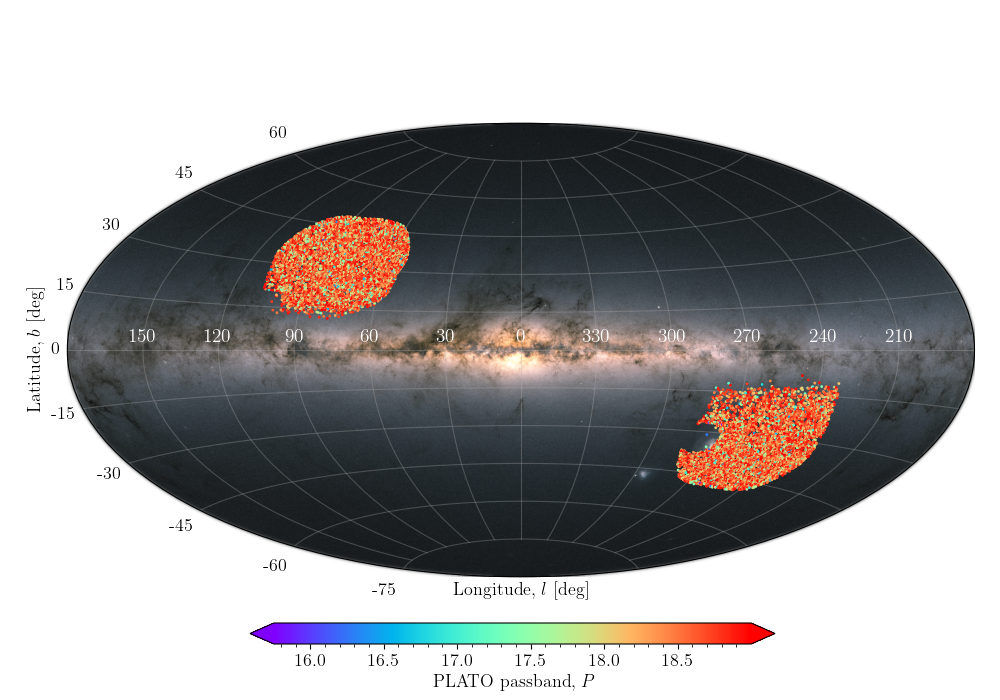

In [30]:
fig, ax = pt.drawStarsInSkyAitoff(dt3.ra, dt3.dec, magStars=dt3.Pmag, fs=13, figsize=(10,7))
fig.savefig(f'{fdir}/aitoff_projection.png', bbox_inches='tight', dpi=300)

In [ ]:
# dx = dt[(dt.z > 0.9) & (dt.z < 1.2)]
# dx = dt[(dt.z < 0.9)]
# fig, ax = pt.drawStarsInSkyAitoff(dx.ra, dx.dec, magStars=dx.Pmag, fs=14, figsize=(10,7))